In [1]:
#IMPORT THE LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'

In [18]:
%matplotlib inline
#Data Import
eod_dat_csv = pd.read_csv('https://hilpisch.com/tr_eikon_eod_data.csv')
eod_dat_csv['Date'] = pd.to_datetime(eod_dat_csv['Date'],errors='coerce')
eod_dat_csv.set_index('Date',inplace=True)
#eod_dat_csv.info()
eod_correlation_data= eod_dat_csv[['.SPX','.VIX']].dropna()
eod_correlation_data.tail()

,.SPX,.VIX
Date,,
2018-06-25,2717.07,17.33
2018-06-26,2723.06,15.92
2018-06-27,2699.63,17.91
2018-06-28,2716.31,16.85
2018-06-29,2718.37,16.09


In [19]:
eod_correlation_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2138 non-null   float64
 1   .VIX    2138 non-null   float64
dtypes: float64(2)
memory usage: 50.1 KB


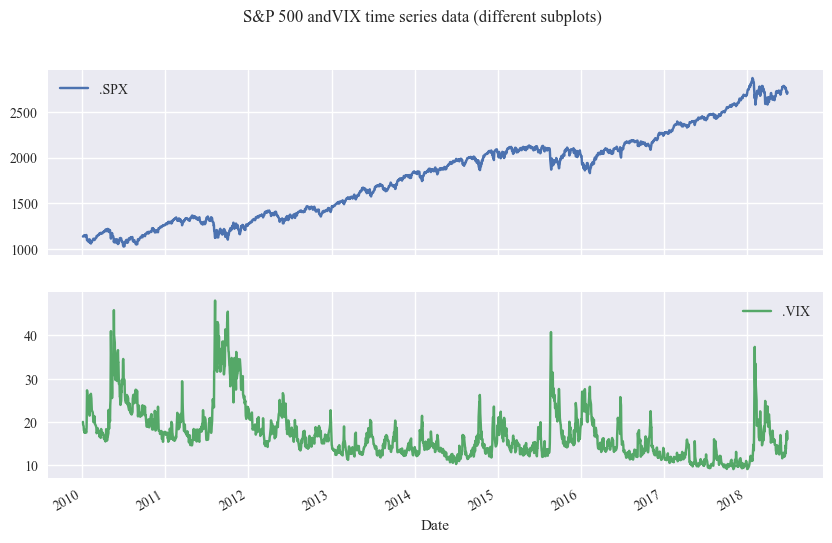

In [20]:
eod_correlation_data.plot(
    subplots=True,
    figsize=(10,6),
    title='S&P 500 andVIX time series data (different subplots)'
)
plt.show()

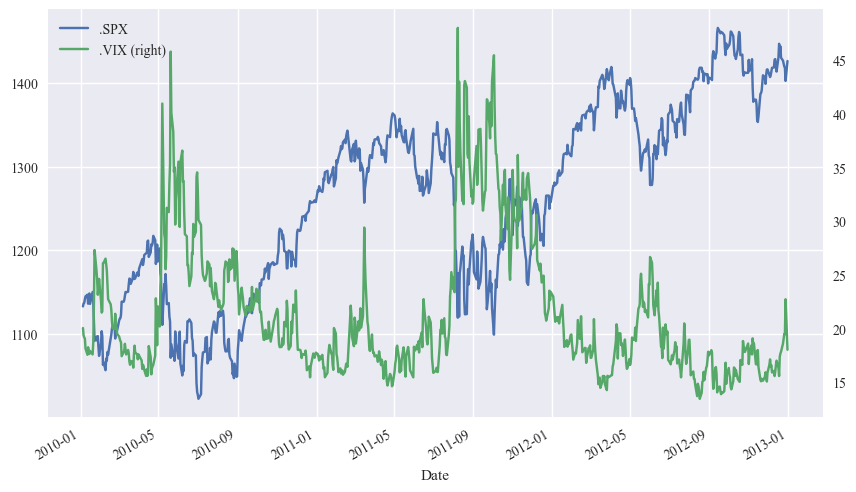

In [21]:
eod_correlation_data.loc[:'2012-12-31'].plot(secondary_y='.VIX',figsize=(10,6));
plt.show()

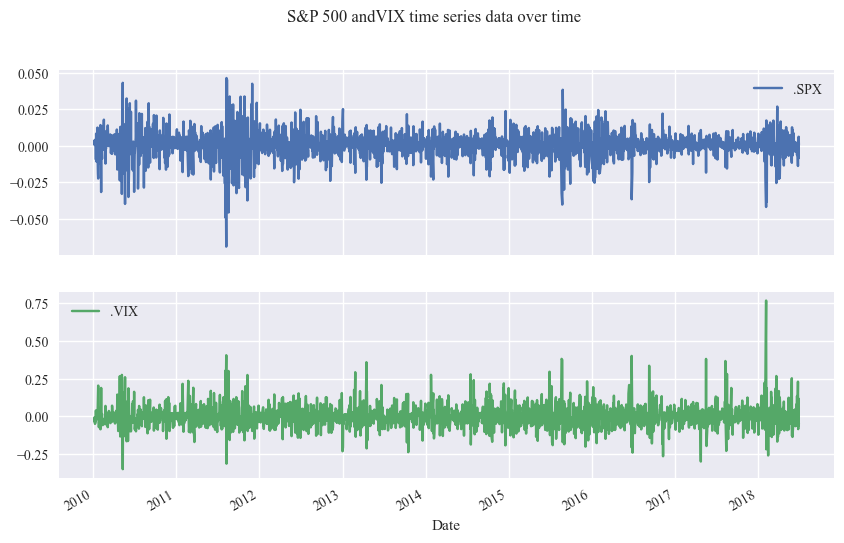

In [25]:
#LOGARITHMIC RETURNS
rets = np.log(eod_correlation_data/eod_correlation_data.shift(1))
rets.dropna(inplace=True)
rets.plot(subplots=True,
          figsize=(10,6),
          title='S&P 500 andVIX time series data over time');
plt.show()

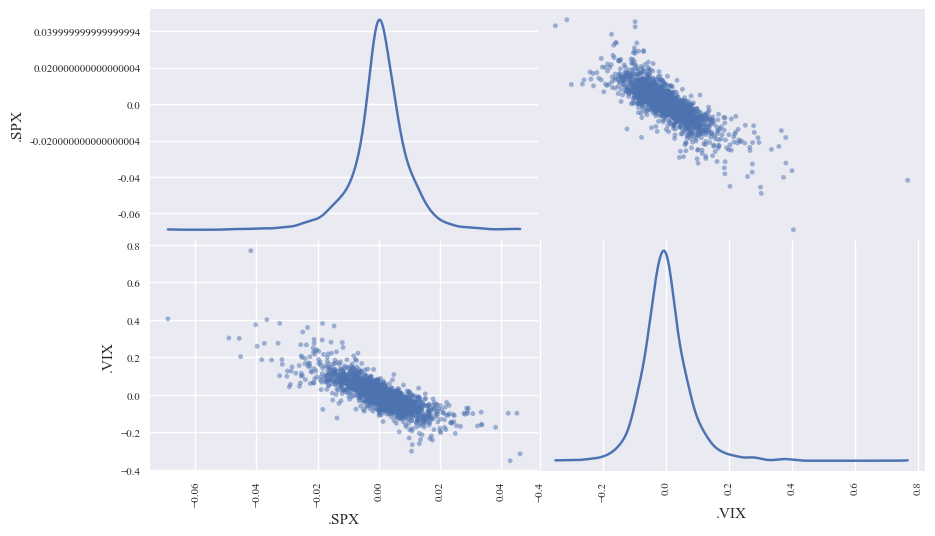

In [44]:
pd.plotting.scatter_matrix(rets,
                           figsize=(10,6),
                           diagonal='kde',
                           hist_kwds={'bins':35},
                           range_padding=0.1);

plt.show()

<Figure size 1000x600 with 0 Axes>

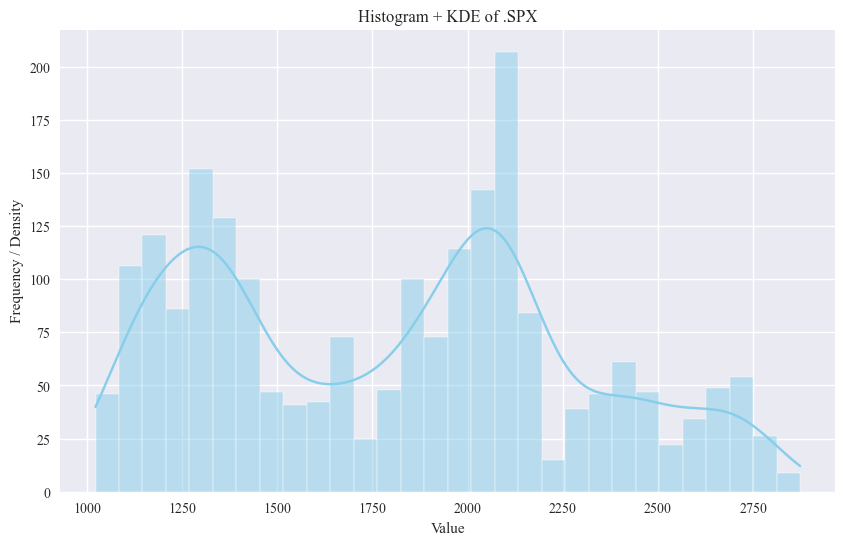

In [36]:

# Example: pick one column, say "S&P 500"
col = ".SPX"

plt.figure(figsize=(10,6))
sns.histplot(eod_correlation_data[col], bins=30, kde=True, color="skyblue")

plt.title(f"Histogram + KDE of {col}")
plt.xlabel("Value")
plt.ylabel("Frequency / Density")
plt.show()

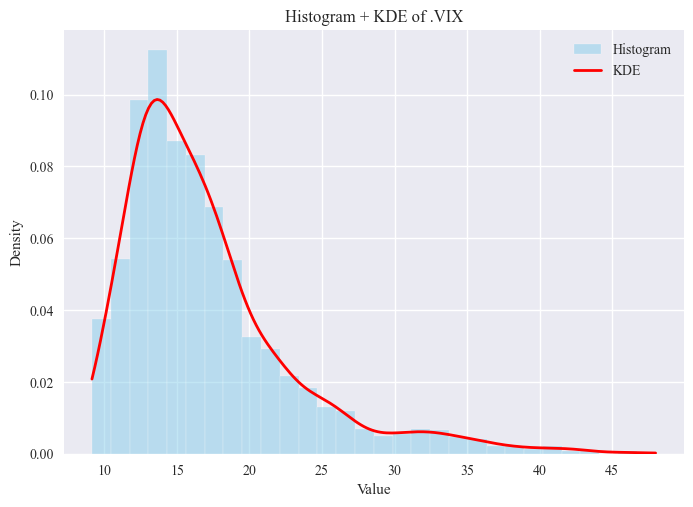

In [37]:

from scipy.stats import gaussian_kde

col = ".VIX"  # pick another column, e.g., VIX
data = eod_correlation_data[col].dropna()

# Histogram
plt.hist(data, bins=30, density=True, alpha=0.5, color="skyblue", label="Histogram")

# KDE
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 200)
plt.plot(x, kde(x), color="red", linewidth=2, label="KDE")

plt.title(f"Histogram + KDE of {col}")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

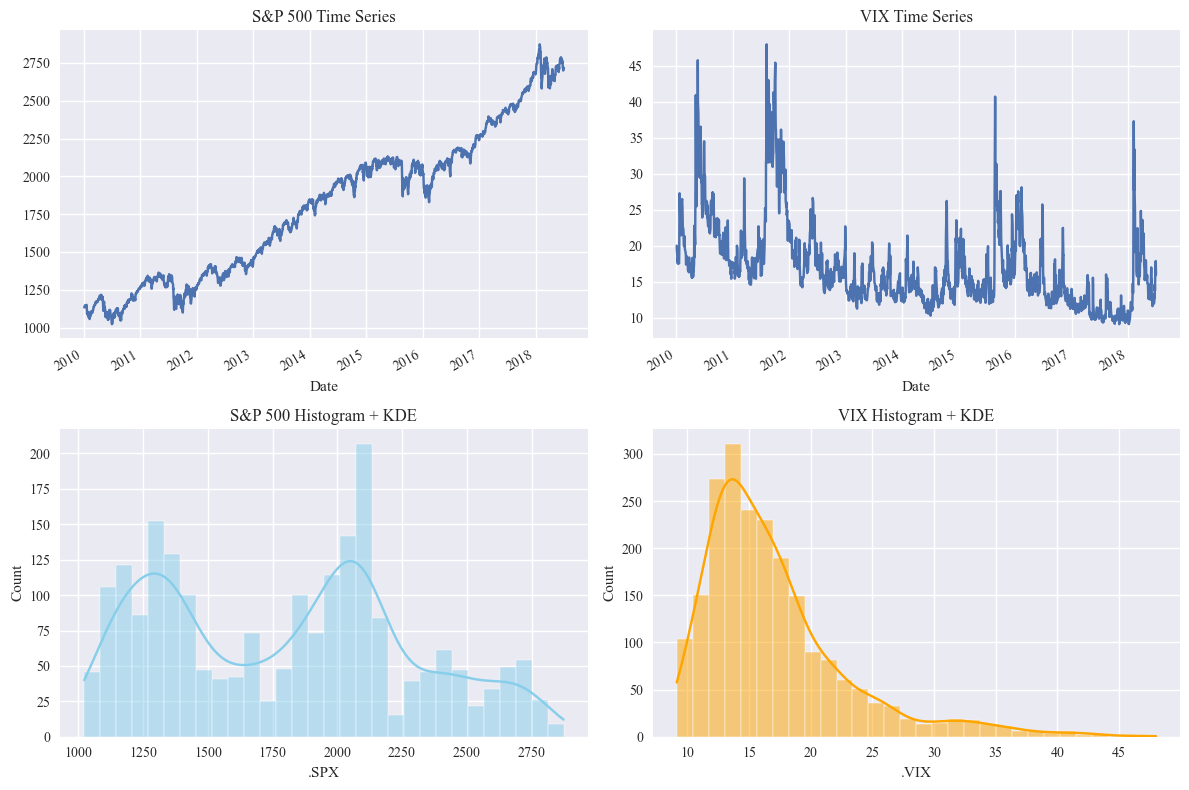

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Time series plot
eod_correlation_data['.SPX'].plot(ax=axes[0,0], title="S&P 500 Time Series")
eod_correlation_data['.VIX'].plot(ax=axes[0,1], title="VIX Time Series")

# Histogram + KDE for S&P 500
sns.histplot(eod_correlation_data['.SPX'], bins=30, kde=True, ax=axes[1,0], color="skyblue")
axes[1,0].set_title("S&P 500 Histogram + KDE")

# Histogram + KDE for VIX
sns.histplot(eod_correlation_data['.VIX'], bins=30, kde=True, ax=axes[1,1], color="orange")
axes[1,1].set_title("VIX Histogram + KDE")

plt.tight_layout()
plt.show()

OLS REGRESSION

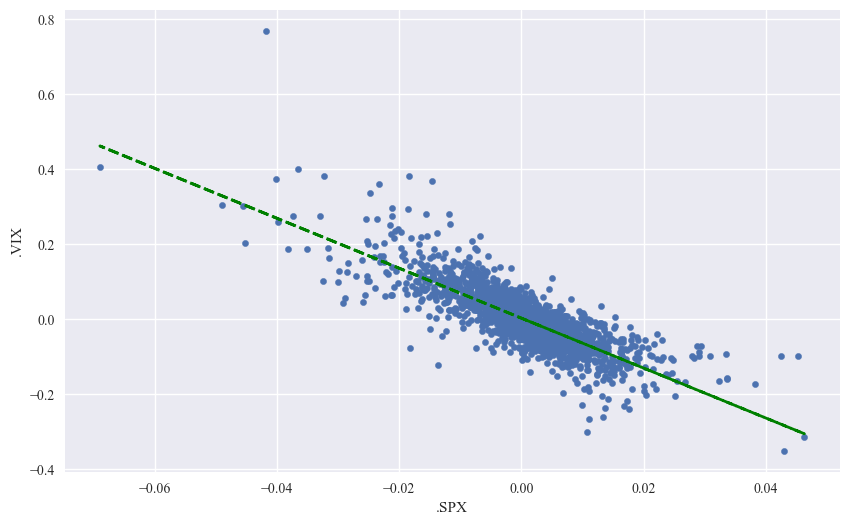

In [60]:
reg = np.polyfit(rets['.SPX'],rets['.VIX'],deg = 1)
ax = rets.plot(kind='scatter',x = '.SPX',y = '.VIX',figsize=(10,6))
ax.plot(rets['.SPX'],np.polyval(reg,rets['.SPX']),'g--',linewidth=2);
plt.show()